[Algorithm complexity](https://en.wikipedia.org/wiki/Computational_complexity) is a very important topic in algorithm design. It represents how the time or space required by an algorithm grows as the size of the input grows. In this notebook, we will discuss the time complexity of algorithms (one can also analyze the space complexity of algorithms in a similar way).

## Theory

The time complexity of an algorithm is a function describing the amount of time an algorithm takes in terms of the amount of input to the algorithm. It is commonly expressed using the big-$\mathcal{O}$ notation.

Strictly speaking, big-$\mathcal{O}$ is a set of all functions that grow at most as fast as a given function:

$$
f(n) \in \mathcal{O}(g(n))
$$
means that
$$
\forall n_0 \in \mathbb{N},\; \exists C > 0:\; \forall n > n_0\;\; 0 \leq f(n) \leq C \cdot g(n).
$$

In other words, for large enough $n$, the function $f(n)$ is bounded from above by a constant multiple of $g(n)$.

__Note__: here a function $f:\;\mathbb{N} \rightarrow \mathbb{R}$ is a time complexity of an algorithm: it can be the number of operations, the number of comparisons, the number of memory accesses, etc.

## Common time complexities
Here are some common time complexities of algorithms with examples (from fastest to slowest):
- $\mathcal{O}(1)$ - constant time complexity:
    - accessing an element in an array by index;
    - appending an element to the end of a list;
    - retrieving the first element of a list;
    - retrieving an element from a set or a dictionary by key...
- $\mathcal{O}(\log n)$ - logarithmic time complexity
    - binary search in a sorted array;
    - finding the largest/smallest element in a binary search tree...
- $\mathcal{O}(n)$ - linear time complexity
    - finding the maximum element in an array;
    - finding the sum of elements in an array...
- $\mathcal{O}(n \log n)$ - linearithmic time complexity
    - sorting an array using mergesort...
- $\mathcal{O}(n^2)$ - quadratic time complexity
    - bubble sort;
    - finding all pairs of elements in an array that sum up to a given value...
- $\mathcal{O}(2^n)$ - exponential time complexity
    - finding all subsets of a set...
- $\mathcal{O}(n!)$ - factorial time complexity
    - finding all permutations of a set;
    - bogosort...
- $\mathcal{O}(n^n)$ - super-exponential time complexity


In [ ]:
%pip install numpy matplotlib scipy

## Numerical analysis

In [112]:
from timeit import repeat, timeit
from statistics import mean, stdev
from typing import Callable
import random

import numpy as np
import scipy.optimize as opt
from tqdm import tqdm
import matplotlib.pyplot as plt

# use pretty matplotlib style
plt.style.use('bmh')

### $\mathcal{O}(1)$

(Constant time complexity means that the time required by an algorithm does not depend on the size of the input.)

Example: access an element in an array by index.

In [98]:
def benchmark_list_access(n: int) -> float:
    lst = list(range(n))
    N_repeats = 1000000
    times = repeat('lst[3]', globals={'lst': lst}, number=N_repeats, repeat=100)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [103]:
n_range_access = np.logspace(1, 6, num=50, dtype=int, base=10)
benchmark_res = [benchmark_list_access(n) for n in n_range_access]
mean_values_access, std_values_access = zip(*benchmark_res)

In [104]:
mean_of_means = mean(mean_values_access)

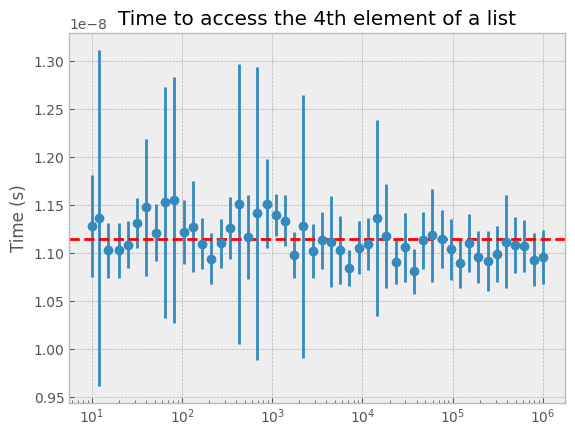

In [116]:
plt.errorbar(n_range_access, mean_values_access, yerr=std_values_access, fmt='o')
plt.axhline(y=mean_of_means, color='r', linestyle='--', label='Mean time (constant)')
plt.xscale('log')
plt.ylabel('Time (s)')
plt.title('Time to access the 4th element of a list')
plt.grid(True)
plt.show()

### $\mathcal{O}(\log n)$

Example: binary search in a sorted array.

In [29]:
def bin_search(lst: list[int], target: int) -> int:
    low = 0
    high = len(lst) - 1
    while low <= high:
        mid = (low + high) // 2
        if lst[mid] == target:
            return mid
        elif lst[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1

bin_search([2, 5, 6, 8, 9, 12, 12], 6)

2

In [30]:
def benchmark_bin_search(n: int) -> tuple[float, float]:
    lst = list(range(n))
    target = n - 1 # worst case scenario
    N_repeats = 200
    times = repeat("bin_search(lst, target)", globals={"bin_search": bin_search, "lst": lst, "target": target}, number=N_repeats, repeat=1000)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [107]:
n_range_bin_search = np.linspace(10**2, 10**5, 200, dtype=int)
benchmark_res = [benchmark_bin_search(n) for n in n_range_bin_search]
mean_values_bin_search, std_values_bin_search = zip(*benchmark_res)

In [108]:
# fit to a logarithmic curve
def log_curve(x: float, a: float, b: float, c: float):
    return a * np.log(b * x) + c

params, _ = opt.curve_fit(log_curve, n_range_bin_search, mean_values_bin_search)

C:\Users\avaliullin\AppData\Local\Temp\ipykernel_6176\93101952.py:3: RuntimeWarning: invalid value encountered in log
  return a * np.log(b * x) + c


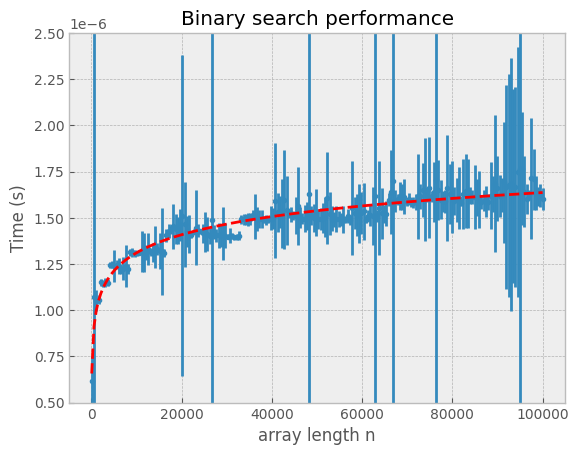

In [117]:
plt.plot(n_range_bin_search, log_curve(np.array(n_range_bin_search), *params), color='r', linestyle='--', zorder=2)
plt.errorbar(n_range_bin_search, mean_values_bin_search, yerr=std_values_bin_search, fmt='.', zorder=1)
plt.ylim(np.array([0.5, 2.5]) * 1e-6)
plt.xlabel('array length n')
plt.ylabel('Time (s)')
plt.title('Binary search performance')
plt.grid(True)
plt.show()

In [74]:
my_n = 10000
print(f'Binary search time complexity for n = {my_n}: {log_curve(my_n, *params):e} s')

Binary search time complexity for n = 10000: 1.317104e-06 s


### $\mathcal{O}(n)$

Example: sum of elements in an array.

In [120]:
def mysum(lst: list[int]) -> int:
    total = 0
    for i in lst:
        total += i
    return total

In [119]:
def benchmark_sum(n: int, func: Callable[[int], int]) -> tuple[float, float]:
    lst = list(range(n))
    N_repeats = 100
    times = repeat("func(lst)", globals={"func": func, "lst": lst}, number=N_repeats, repeat=200)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [121]:
# this may take a while
n_values_lin = np.linspace(10**2, 10**4, 100, dtype=int)
benchmark_res_mysum = [benchmark_sum(n, mysum) for n in tqdm(n_values_lin)]
mean_values_mysum, std_values_mysum = zip(*benchmark_res_mysum)

100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


In [122]:
benchmark_res_sum = [benchmark_sum(n, sum) for n in tqdm(n_values_lin)]
mean_values_sum, std_values_sum = zip(*benchmark_res_sum)

In [123]:
# fit lines using np.polyfit
degree = 1
params_mysum = np.polyfit(n_values_lin, mean_values_mysum, degree)
params_sum = np.polyfit(n_values_lin, mean_values_sum, degree)

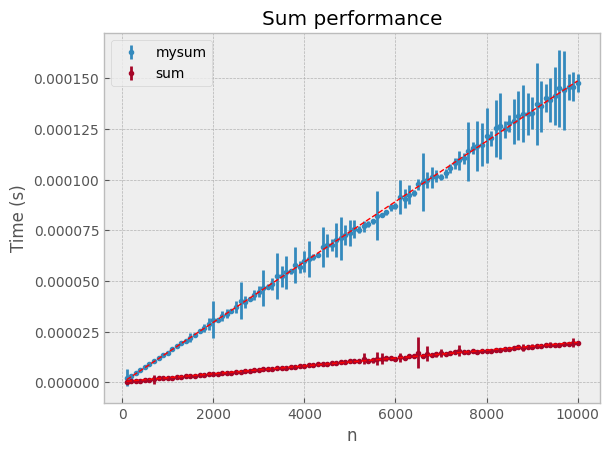

In [124]:
plt.errorbar(n_values_lin, mean_values_mysum, yerr=std_values_mysum, fmt='.', zorder=1, label='mysum')
plt.errorbar(n_values_lin, mean_values_sum, yerr=std_values_sum, fmt='.', zorder=1, label='sum')
plt.plot(n_values_lin, np.polyval(params_mysum, n_values_lin), color='r', linestyle='--', zorder=2, linewidth=1)
plt.plot(n_values_lin, np.polyval(params_sum, n_values_lin), color='r', linestyle='--', zorder=2, linewidth=1)
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Sum performance')
plt.grid(True)
plt.legend()
plt.show()

### $\mathcal{O}(n \log n)$

Example: array sorting using mergesort and built-in python `sorted` function.

In [41]:
def merge(left, right):
    result = []
    i = j = 0
    # Merge the two lists together until one is empty
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    # If left list is empty, append the rest of right list
    while i < len(left):
        result.append(left[i])
        i += 1
    # If right list is empty, append the rest of left list
    while j < len(right):
        result.append(right[j])
        j += 1
    return result

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    return merge(merge_sort(arr[:mid]), merge_sort(arr[mid:]))

In [46]:
def benchmark_sort_function(n: int, func: Callable[[list[int]], list[int]]) -> tuple[float, float]:
    lst = random.choices(range(10**4), k=n)
    N_repeats = 40
    times = repeat("func(lst)", globals={"func": func, "lst": lst}, number=N_repeats, repeat=5)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [52]:
n_range_sorting = np.linspace(10**1, 5 * 10**3, 500, dtype=int)
benchmark_res_merge_sort = [benchmark_sort_function(n, merge_sort) for n in tqdm(n_range_sorting)]
mean_values_merge_sort, std_values_merge_sort = zip(*benchmark_res_merge_sort)

100%|██████████| 500/500 [04:11<00:00,  1.99it/s]


In [53]:
benchmark_res_sorted = [benchmark_sort_function(n, sorted) for n in tqdm(n_range_sorting)]
mean_values_sorted, std_values_sorted = zip(*benchmark_res_sorted)

100%|██████████| 500/500 [00:15<00:00, 33.31it/s] 


In [55]:
# fit to a logarithmic curve
def nlog_curve(x: float, a: float, b: float, c: float):
    return a * x * np.log(b * x) + c

params_merge_sort, _ = opt.curve_fit(nlog_curve, n_range_sorting, mean_values_merge_sort)
params_sorted, _ = opt.curve_fit(nlog_curve, n_range_sorting, mean_values_sorted)

C:\Users\avaliullin\AppData\Local\Temp\ipykernel_6176\926792306.py:3: RuntimeWarning: invalid value encountered in log
  return a * x * np.log(b * x) + c


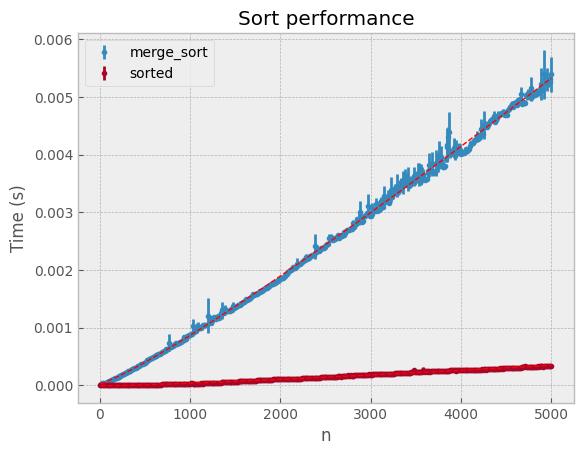

In [125]:
plt.errorbar(n_range_sorting, mean_values_merge_sort, yerr=std_values_merge_sort, fmt='.', zorder=1, label='merge_sort')
plt.errorbar(n_range_sorting, mean_values_sorted, yerr=std_values_sorted, fmt='.', zorder=1, label='sorted')
plt.plot(n_range_sorting, nlog_curve(np.array(n_range_sorting), *params_merge_sort), color='r', linestyle='--', zorder=2, linewidth=1)
plt.plot(n_range_sorting, nlog_curve(np.array(n_range_sorting), *params_sorted), color='r', linestyle='--', zorder=2, linewidth=1)
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Sort performance')
plt.grid(True)
plt.legend()
plt.show()

### $\mathcal{O}(n^2)$

Example: sum of the pairwise products of elements in an array.

E.g.: `sum_pairs([1, 2, 3])` $ = 1 \cdot 2 + 1 \cdot 3 + 2 \cdot 3 = 11$.

Note: this algorithm can be optimized to $\mathcal{O}(n)$ using some clever math. 

For example, for $n=3$:
$$
(a+b+c)^2 = a^2 + b^2 + c^2 + 2(ab + ac + bc).
$$
And, in general, for $n$ elements:
$$
\left(\sum_{i=1}^n a_i\right)^2 = \sum_{i=1}^n a_i^2 + 2 \sum_{i\neq j} a_i a_j.
$$
Use this fact to complete the `sum_pairs_linear` function below.

In [84]:
def sum_pairs(lst: list[int]) -> int:
    total = 0
    for i in range(len(lst)):
        for j in range(i + 1, len(lst)):
            total += lst[i] * lst[j]
    return total


from itertools import combinations
def sum_pairs_optimized(lst: list[int]) -> int:
    """Same as sum_pairs, but using itertools.combinations to generate pairs of indices."""
    return sum(a * b for a, b in combinations(lst, 2))


def sum_pairs_linear(lst: list[int]) -> int:
    sum_squared = sum(lst)**2
    sum_of_squares = sum(x**2 for x in lst)
    return (sum_squared - sum_of_squares) // 2

Test that all three functions return the same result for the same input.

In [134]:
TESTS = [
    ([1, 2, 3, 4, 5], 85),
    ([2, 6], 12),
    ([4, 0, 2, 1], 14),
    (list(range(1, 101)), 12582075),
]
for tst in TESTS:
    assert sum_pairs(tst[0]) == tst[1], f"Failed for {tst[0]}"
    assert sum_pairs_optimized(tst[0]) == tst[1], f"Failed for {tst[0]}"
    assert sum_pairs_linear(tst[0]) == tst[1], f"Failed for {tst[0]}"

In [85]:
def benchmark_sum_pairs(n: int, func: Callable[[list[int]], int]) -> tuple[float, float]:
    lst = random.choices(range(10**4), k=n)
    N_repeats = 10
    times = repeat("func(lst)", globals={"func": func, "lst": lst}, number=N_repeats, repeat=10)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [87]:
n_range_sum_pairs = np.linspace(10**1, 10**3, 100, dtype=int)
benchmark_res_sum_pairs = [benchmark_sum_pairs(n, sum_pairs) for n in tqdm(n_range_sum_pairs)]
mean_values_sum_pairs, std_values_sum_pairs = zip(*benchmark_res_sum_pairs)

100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


In [88]:
benchmark_sum_pairs_optimized = [benchmark_sum_pairs(n, sum_pairs_optimized) for n in tqdm(n_range_sum_pairs)]
mean_values_sum_pairs_optimized, std_values_sum_pairs_optimized = zip(*benchmark_sum_pairs_optimized)

100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


In [89]:
benchmark_sum_pairs_linear = [benchmark_sum_pairs(n, sum_pairs_linear) for n in tqdm(n_range_sum_pairs)]
mean_values_sum_pairs_linear, std_values_sum_pairs_linear = zip(*benchmark_sum_pairs_linear)

100%|██████████| 100/100 [00:00<00:00, 386.48it/s]


In [90]:
# fit parabolas using np.polyfit
degree = 2
params_sum_pairs = np.polyfit(n_range_sum_pairs, mean_values_sum_pairs, degree)
params_sum_pairs_optimized = np.polyfit(n_range_sum_pairs, mean_values_sum_pairs_optimized, degree)

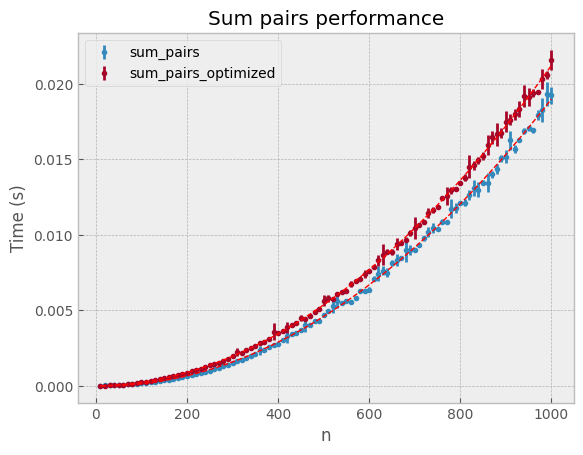

In [126]:
plt.errorbar(n_range_sum_pairs, mean_values_sum_pairs, yerr=std_values_sum_pairs, fmt='.', zorder=1, label='sum_pairs')
plt.errorbar(n_range_sum_pairs, mean_values_sum_pairs_optimized, yerr=std_values_sum_pairs_optimized, fmt='.', zorder=1, label='sum_pairs_optimized')
plt.plot(n_range_sum_pairs, np.polyval(params_sum_pairs, n_range_sum_pairs), color='r', linestyle='--', zorder=2, linewidth=1)
plt.plot(n_range_sum_pairs, np.polyval(params_sum_pairs_optimized, n_range_sum_pairs), color='r', linestyle='--', zorder=2, linewidth=1)
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Sum pairs performance')
plt.legend()
plt.grid(True)

In [93]:
# fit a linear curve to the linear implementation
params_sum_pairs_linear = np.polyfit(n_range_sum_pairs, mean_values_sum_pairs_linear, 1)

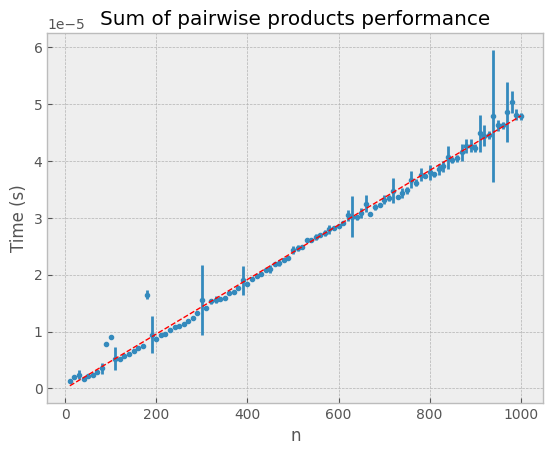

In [129]:
plt.errorbar(n_range_sum_pairs, mean_values_sum_pairs_linear, yerr=std_values_sum_pairs_linear, fmt='.', zorder=1, label='sum_pairs_linear')
plt.plot(n_range_sum_pairs, np.polyval(params_sum_pairs_linear, n_range_sum_pairs), color='r', linestyle='--', zorder=2, linewidth=1)
plt.grid(True)
plt.title('Sum of pairwise products performance')
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.show()